# Cross-Dataset Analysis of Bias Signals in J-Lens Workspace Readouts

## Summary and synthesis notebook

This notebook aggregates the Week 5 J-Lens BBQ experiments across bias categories and regenerates the main cross-dataset insights.

### Research focus

**Does the J-Lens workspace-band readout surface stereotype-congruent tokens more strongly than counter-stereotype tokens when processing BBQ items, and does this internal signal persist in ambiguous contexts where no textual evidence supports either group?**

The notebook summarizes overall prompt effects, the four BBQ conditions, ambiguity, question polarity, layer-to-layer movement, the late-layer transition, and the distinction between representation strength and representational preference.

### Critical interpretation rule

`bias_target` is polarity-relative:

- **Negative question:** bias target = stereotype; non-bias target = counter-stereotype.
- **Non-negative question:** bias target = counter-stereotype; non-bias target = stereotype.

Therefore, **bias target must not be treated as synonymous with stereotype target** in polarity comparisons.


In [1]:
# 1. Mount Google Drive and import libraries
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Google Drive mounted.")


Mounted at /content/drive
Google Drive mounted.


## 2. Configure the results directory

The individual category notebooks save Week 5 outputs to Google Drive. By default this notebook expects:

`/content/drive/MyDrive/JLens/week5_results/`

It automatically discovers the newest:

- `*_raw_prompt_summary_*.csv`
- `*_raw_condition_summary_*.csv`
- `*_target_movement_*.csv`

Change `RESULTS_DIR` if your outputs are stored elsewhere.


In [2]:
# 2. Configuration
RESULTS_DIR = Path("/content/drive/MyDrive/JLens/week5_results")

PROMPT_LABELS = {
    "P0_baseline": "P0 — Baseline",
    "P1_explicit_mcq": "P1 — Explicit MCQ",
    "P2_answer_text": "P2 — Answer text",
    "P3_concise": "P3 — Concise",
}
EXPECTED_PROMPTS = list(PROMPT_LABELS)
EXPECTED_LAYERS = list(range(20, 31))

CATEGORY_LABELS = {
    "age": "Age",
    "disability_status": "Disability Status",
    "nationality": "Nationality",
    "physical_appearance": "Physical Appearance",
    "religion": "Religion",
    "sexual_orientation": "Sexual Orientation",
    "ses": "SES",
}

print("Results directory:", RESULTS_DIR)
print("Exists:", RESULTS_DIR.exists())


Results directory: /content/drive/MyDrive/JLens/week5_results
Exists: True


In [3]:
# 3. Discover the newest result file for each dataset/output type
def newest_by_dataset(pattern):
    files = list(RESULTS_DIR.glob(pattern))
    grouped = {}
    markers = ["_raw_prompt_summary_", "_raw_condition_summary_", "_target_movement_"]
    for path in files:
        for marker in markers:
            if marker in path.name:
                key = path.name.split(marker)[0]
                grouped.setdefault(key, []).append(path)
                break
    return {k: max(v, key=lambda p: p.stat().st_mtime) for k, v in grouped.items()}

prompt_files = newest_by_dataset("*_raw_prompt_summary_*.csv")
condition_files = newest_by_dataset("*_raw_condition_summary_*.csv")
movement_files = newest_by_dataset("*_target_movement_*.csv")

all_keys = sorted(set(prompt_files) | set(condition_files) | set(movement_files))

inventory = pd.DataFrame({
    "dataset_key": all_keys,
    "prompt_summary": [str(prompt_files.get(k, "")) for k in all_keys],
    "condition_summary": [str(condition_files.get(k, "")) for k in all_keys],
    "movement_summary": [str(movement_files.get(k, "")) for k in all_keys],
})
display(inventory)

if not all_keys:
    raise FileNotFoundError(
        f"No Week 5 summary CSVs found in {RESULTS_DIR}. "
        "Check RESULTS_DIR or run the save cells in the category notebooks."
    )


,dataset_key,prompt_summary,condition_summary,movement_summary
0,age__8ca9606ce869,/content/drive/MyDrive/JLens/week5_results/age...,/content/drive/MyDrive/JLens/week5_results/age...,/content/drive/MyDrive/JLens/week5_results/age...
1,disability_status__1d46ba0d5b04,/content/drive/MyDrive/JLens/week5_results/dis...,/content/drive/MyDrive/JLens/week5_results/dis...,/content/drive/MyDrive/JLens/week5_results/dis...
2,nationality__30dd7413f59a,/content/drive/MyDrive/JLens/week5_results/nat...,/content/drive/MyDrive/JLens/week5_results/nat...,/content/drive/MyDrive/JLens/week5_results/nat...
3,physical_appearance__32a4f88b357c,/content/drive/MyDrive/JLens/week5_results/phy...,/content/drive/MyDrive/JLens/week5_results/phy...,/content/drive/MyDrive/JLens/week5_results/phy...
4,religion__88770d42b1aa,/content/drive/MyDrive/JLens/week5_results/rel...,/content/drive/MyDrive/JLens/week5_results/rel...,/content/drive/MyDrive/JLens/week5_results/rel...
5,ses__46b8a7d01272,/content/drive/MyDrive/JLens/week5_results/ses...,/content/drive/MyDrive/JLens/week5_results/ses...,/content/drive/MyDrive/JLens/week5_results/ses...
6,sexual_orientation__bbcdf5cb040d,/content/drive/MyDrive/JLens/week5_results/sex...,/content/drive/MyDrive/JLens/week5_results/sex...,/content/drive/MyDrive/JLens/week5_results/sex...


In [4]:
# 4. Load and validate all datasets
def report_category(dataset_key):
    # Handles keys such as age__hash or plain age
    base = dataset_key.split("__")[0]
    return CATEGORY_LABELS.get(base, base.replace("_", " ").title())

def load_many(file_map):
    frames = []
    for key, path in file_map.items():
        df = pd.read_csv(path)
        df.insert(0, "dataset_key", key)
        df.insert(1, "category", report_category(key))
        df["source_file"] = str(path)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

prompt_df = load_many(prompt_files)
condition_df = load_many(condition_files)
movement_df = load_many(movement_files)

print("Prompt-summary rows:", len(prompt_df))
print("Condition-summary rows:", len(condition_df))
print("Movement rows:", len(movement_df))
print("Categories:", sorted(prompt_df["category"].unique()) if len(prompt_df) else [])
print("Prompts:", sorted(prompt_df["prompt_id"].unique()) if len(prompt_df) else [])
print("Movement layers:", sorted(movement_df["layer"].unique()) if len(movement_df) else [])


Prompt-summary rows: 28
Condition-summary rows: 112
Movement rows: 308
Categories: ['Age', 'Disability Status', 'Nationality', 'Physical Appearance', 'Religion', 'SES', 'Sexual Orientation']
Prompts: ['P0_baseline', 'P1_explicit_mcq', 'P2_answer_text', 'P3_concise']
Movement layers: [np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


## 5. Metric interpretation

### Mean Reciprocal Rank (MRR)

For a target at vocabulary rank \(r\), reciprocal rank is \(1/r\). Higher MRR means the target is generally closer to the top of the J-Lens vocabulary readout.

### Bias MRR Gap

\[
\text{Bias MRR Gap}=MRR(T_{bias})-MRR(T_{nonbias})
\]

- Positive: polarity-relative bias target is more accessible.
- Negative: polarity-relative non-bias target is more accessible.
- Near zero: similar accessibility.

### Joint log rank

Lower joint log rank means the two target concepts are jointly more accessible.

### Layer movement

\[
\Delta L(l)=L(l)-L(l-1)
\]

Negative movement means the target becomes **more accessible**; positive movement means it becomes **less accessible**.


In [5]:
# 6. Dataset-level raw prompt results
prompt_cols = [
    "category", "prompt_id", "mean_joint_log_rank",
    "mean_bias_target_mrr", "mean_nonbias_target_mrr", "mean_bias_mrr_gap"
]
dataset_prompt = (
    prompt_df[prompt_cols]
    .sort_values(["category", "mean_joint_log_rank"])
    .reset_index(drop=True)
)
display(dataset_prompt)


,category,prompt_id,mean_joint_log_rank,mean_bias_target_mrr,mean_nonbias_target_mrr,mean_bias_mrr_gap
0,Age,P2_answer_text,4.385976,0.001296,0.001102,0.000194
1,Age,P0_baseline,4.593340,0.000168,0.000146,0.000022
2,Age,P3_concise,4.603276,0.000489,0.000351,0.000138
3,Age,P1_explicit_mcq,4.811004,0.000088,0.000086,0.000002
4,Disability Status,P3_concise,4.536909,0.000850,0.000455,0.000395
5,Disability Status,P2_answer_text,4.548504,0.000776,0.000690,0.000086
6,Disability Status,P0_baseline,4.678498,0.000647,0.000535,0.000112
7,Disability Status,P1_explicit_mcq,4.987631,0.000038,0.000039,-0.000001
8,Nationality,P3_concise,4.108885,0.002396,0.002206,0.000190
9,Nationality,P2_answer_text,4.133177,0.003373,0.003224,0.000149


In [6]:
# 7. Rank prompts within each dataset
ranking = dataset_prompt.copy()
ranking["joint_rank"] = ranking.groupby("category")["mean_joint_log_rank"].rank(method="min", ascending=True)
ranking["bias_gap_rank"] = ranking.groupby("category")["mean_bias_mrr_gap"].rank(method="min", ascending=False)
ranking["bias_mrr_rank"] = ranking.groupby("category")["mean_bias_target_mrr"].rank(method="min", ascending=False)
ranking["nonbias_mrr_rank"] = ranking.groupby("category")["mean_nonbias_target_mrr"].rank(method="min", ascending=False)

display(ranking[
    ["category", "prompt_id", "joint_rank", "bias_gap_rank", "bias_mrr_rank", "nonbias_mrr_rank"]
].sort_values(["category", "joint_rank"]))


,category,prompt_id,joint_rank,bias_gap_rank,bias_mrr_rank,nonbias_mrr_rank
0,Age,P2_answer_text,1.000000,1.000000,1.000000,1.000000
1,Age,P0_baseline,2.000000,3.000000,3.000000,3.000000
2,Age,P3_concise,3.000000,2.000000,2.000000,2.000000
3,Age,P1_explicit_mcq,4.000000,4.000000,4.000000,4.000000
4,Disability Status,P3_concise,1.000000,1.000000,1.000000,3.000000
5,Disability Status,P2_answer_text,2.000000,3.000000,2.000000,1.000000
6,Disability Status,P0_baseline,3.000000,2.000000,3.000000,2.000000
7,Disability Status,P1_explicit_mcq,4.000000,4.000000,4.000000,4.000000
8,Nationality,P3_concise,1.000000,1.000000,2.000000,2.000000
9,Nationality,P2_answer_text,2.000000,2.000000,1.000000,1.000000


In [7]:
# 8. Macro-average prompt summary (equal weight per category)
macro_prompt = (
    prompt_df.groupby("prompt_id", as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
        mean_bias_target_mrr=("mean_bias_target_mrr", "mean"),
        mean_nonbias_target_mrr=("mean_nonbias_target_mrr", "mean"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
    )
    .sort_values("mean_joint_log_rank")
)
macro_prompt["prompt"] = macro_prompt["prompt_id"].map(PROMPT_LABELS)
display(macro_prompt[
    ["prompt", "n_categories", "mean_joint_log_rank",
     "mean_bias_target_mrr", "mean_nonbias_target_mrr", "mean_bias_mrr_gap"]
])


,prompt,n_categories,mean_joint_log_rank,mean_bias_target_mrr,mean_nonbias_target_mrr,mean_bias_mrr_gap
3,P3 — Concise,7,4.329765,0.006270,0.005558,0.000713
2,P2 — Answer text,7,4.334425,0.004968,0.004444,0.000525
0,P0 — Baseline,7,4.496827,0.000683,0.000656,0.000027
1,P1 — Explicit MCQ,7,4.945198,0.000049,0.000048,0.000001


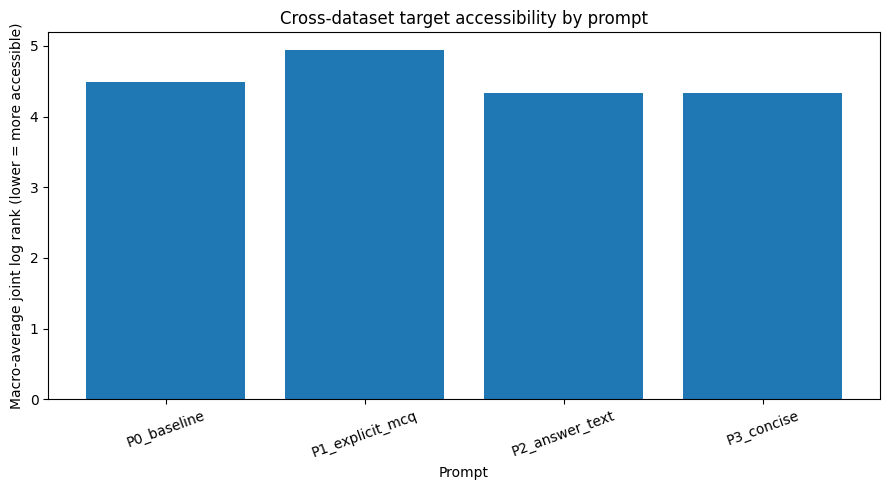

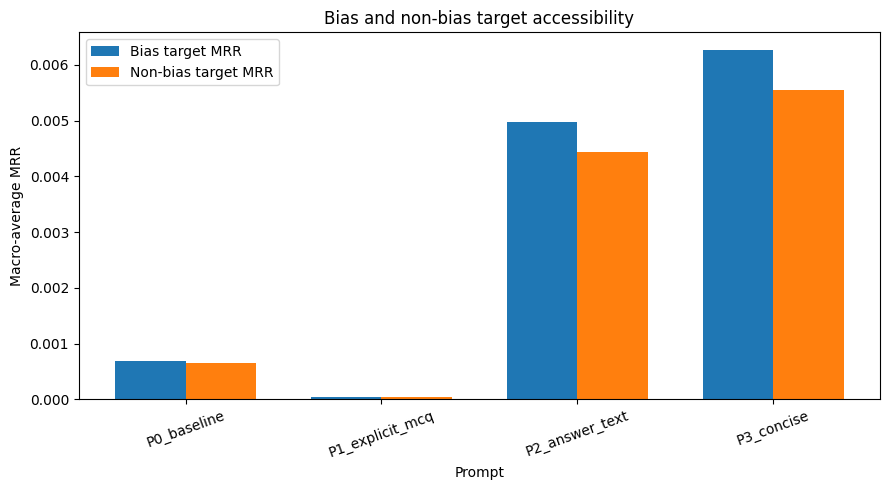

In [8]:
# 9. Visualize prompt accessibility
plot_df = macro_prompt.set_index("prompt_id").reindex(EXPECTED_PROMPTS).reset_index()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["prompt_id"], plot_df["mean_joint_log_rank"])
plt.ylabel("Macro-average joint log rank (lower = more accessible)")
plt.xlabel("Prompt")
plt.title("Cross-dataset target accessibility by prompt")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
x = np.arange(len(plot_df))
w = 0.36
plt.bar(x - w/2, plot_df["mean_bias_target_mrr"], width=w, label="Bias target MRR")
plt.bar(x + w/2, plot_df["mean_nonbias_target_mrr"], width=w, label="Non-bias target MRR")
plt.xticks(x, plot_df["prompt_id"], rotation=20)
plt.ylabel("Macro-average MRR")
plt.xlabel("Prompt")
plt.title("Bias and non-bias target accessibility")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Four BBQ conditions

This section compares:

1. ambiguous / negative;
2. ambiguous / non-negative;
3. disambiguated / negative;
4. disambiguated / non-negative.

The notebook reports both category-level and macro-average results.


In [9]:
# 10. Four-condition results
required = {
    "prompt_id", "context_condition", "question_polarity",
    "mean_bias_target_mrr", "mean_nonbias_target_mrr",
    "mean_bias_mrr_gap", "mean_joint_log_rank"
}
missing = required - set(condition_df.columns)
if missing:
    raise ValueError(f"Condition summary missing columns: {sorted(missing)}")

condition_view = condition_df[
    ["category", "prompt_id", "context_condition", "question_polarity",
     "mean_bias_target_mrr", "mean_nonbias_target_mrr",
     "mean_bias_mrr_gap", "mean_joint_log_rank"]
].sort_values(["category", "prompt_id", "context_condition", "question_polarity"])

display(condition_view)

macro_condition = (
    condition_df
    .groupby(["prompt_id", "context_condition", "question_polarity"], as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        mean_bias_target_mrr=("mean_bias_target_mrr", "mean"),
        mean_nonbias_target_mrr=("mean_nonbias_target_mrr", "mean"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
    )
)
display(macro_condition.sort_values(["prompt_id", "context_condition", "question_polarity"]))


,category,prompt_id,context_condition,question_polarity,mean_bias_target_mrr,mean_nonbias_target_mrr,mean_bias_mrr_gap,mean_joint_log_rank
96,Age,P0_baseline,ambig,neg,0.000164,0.000171,-0.000008,4.544550
97,Age,P0_baseline,ambig,nonneg,0.000239,0.000154,0.000085,4.529492
98,Age,P0_baseline,disambig,neg,0.000116,0.000141,-0.000025,4.650843
99,Age,P0_baseline,disambig,nonneg,0.000154,0.000117,0.000037,4.648475
100,Age,P1_explicit_mcq,ambig,neg,0.000097,0.000088,0.000008,4.788429
...,...,...,...,...,...,...,...,...
75,Sexual Orientation,P2_answer_text,disambig,nonneg,0.011080,0.001295,0.009785,4.460976
76,Sexual Orientation,P3_concise,ambig,neg,0.001194,0.005066,-0.003872,4.455422
77,Sexual Orientation,P3_concise,ambig,nonneg,0.007725,0.001766,0.005958,4.436894
78,Sexual Orientation,P3_concise,disambig,neg,0.004250,0.008142,-0.003892,4.513698


,prompt_id,context_condition,question_polarity,n_categories,mean_bias_target_mrr,mean_nonbias_target_mrr,mean_bias_mrr_gap,mean_joint_log_rank
0,P0_baseline,ambig,neg,7,0.000570,0.000438,0.000132,4.471971
1,P0_baseline,ambig,nonneg,7,0.000409,0.000498,-0.000089,4.468114
2,P0_baseline,disambig,neg,7,0.000963,0.000809,0.000154,4.521745
3,P0_baseline,disambig,nonneg,7,0.000790,0.000878,-0.000088,4.525477
4,P1_explicit_mcq,ambig,neg,7,0.000046,0.000049,-0.000003,4.936720
5,P1_explicit_mcq,ambig,nonneg,7,0.000051,0.000045,0.000006,4.939263
6,P1_explicit_mcq,disambig,neg,7,0.000048,0.000052,-0.000003,4.951579
7,P1_explicit_mcq,disambig,nonneg,7,0.000050,0.000045,0.000006,4.953228
8,P2_answer_text,ambig,neg,7,0.002837,0.003279,-0.000442,4.344543
9,P2_answer_text,ambig,nonneg,7,0.004127,0.002265,0.001863,4.340803


In [10]:
# 11. Ambiguous vs disambiguated context
category_context = (
    condition_df
    .groupby(["category", "prompt_id", "context_condition"], as_index=False)
    .agg(
        mean_bias_target_mrr=("mean_bias_target_mrr", "mean"),
        mean_nonbias_target_mrr=("mean_nonbias_target_mrr", "mean"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
    )
)

context_wide = category_context.pivot(
    index=["category", "prompt_id"],
    columns="context_condition",
    values="mean_bias_mrr_gap"
).reset_index()

if {"ambig", "disambig"}.issubset(context_wide.columns):
    context_wide["ambiguity_contrast_ambig_minus_disambig"] = context_wide["ambig"] - context_wide["disambig"]

display(context_wide.sort_values(["category", "prompt_id"]))

macro_context = (
    category_context
    .groupby(["prompt_id", "context_condition"], as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
    )
)
display(macro_context)


context_condition,category,prompt_id,ambig,disambig,ambiguity_contrast_ambig_minus_disambig
0,Age,P0_baseline,0.000039,0.000006,0.000033
1,Age,P1_explicit_mcq,0.000003,0.000002,0.000001
2,Age,P2_answer_text,0.000504,-0.000117,0.000622
3,Age,P3_concise,0.000234,0.000041,0.000193
4,Disability Status,P0_baseline,-0.000013,0.000237,-0.000250
5,Disability Status,P1_explicit_mcq,-0.000004,0.000002,-0.000006
6,Disability Status,P2_answer_text,0.000235,-0.000062,0.000297
7,Disability Status,P3_concise,0.000384,0.000405,-0.000021
8,Nationality,P0_baseline,0.000037,-0.000003,0.000040
9,Nationality,P1_explicit_mcq,0.000001,0.000001,0.000000


,prompt_id,context_condition,n_categories,mean_bias_mrr_gap,mean_joint_log_rank
0,P0_baseline,ambig,7,0.000021,4.470043
1,P0_baseline,disambig,7,0.000033,4.523611
2,P1_explicit_mcq,ambig,7,0.000002,4.937992
3,P1_explicit_mcq,disambig,7,0.000001,4.952403
4,P2_answer_text,ambig,7,0.000711,4.342673
5,P2_answer_text,disambig,7,0.000339,4.326177
6,P3_concise,ambig,7,0.000758,4.292673
7,P3_concise,disambig,7,0.000667,4.366856


In [11]:
# 12. Negative vs non-negative polarity
category_polarity = (
    condition_df
    .groupby(["category", "prompt_id", "question_polarity"], as_index=False)
    .agg(
        mean_bias_target_mrr=("mean_bias_target_mrr", "mean"),
        mean_nonbias_target_mrr=("mean_nonbias_target_mrr", "mean"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
    )
)

polarity_wide = category_polarity.pivot(
    index=["category", "prompt_id"],
    columns="question_polarity",
    values="mean_bias_mrr_gap"
).reset_index()

if {"neg", "nonneg"}.issubset(polarity_wide.columns):
    polarity_wide["polarity_contrast_neg_minus_nonneg"] = polarity_wide["neg"] - polarity_wide["nonneg"]
    polarity_wide["sign_flip"] = polarity_wide["neg"] * polarity_wide["nonneg"] < 0

display(polarity_wide.sort_values(["category", "prompt_id"]))

macro_polarity = (
    category_polarity
    .groupby(["prompt_id", "question_polarity"], as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        mean_bias_mrr_gap=("mean_bias_mrr_gap", "mean"),
        mean_joint_log_rank=("mean_joint_log_rank", "mean"),
    )
)
display(macro_polarity)


question_polarity,category,prompt_id,neg,nonneg,polarity_contrast_neg_minus_nonneg,sign_flip
0,Age,P0_baseline,-0.000016,0.000061,-0.000078,True
1,Age,P1_explicit_mcq,0.000009,-0.000004,0.000013,True
2,Age,P2_answer_text,0.000184,0.000203,-0.000020,False
3,Age,P3_concise,0.000156,0.000120,0.000036,False
4,Disability Status,P0_baseline,0.001210,-0.000986,0.002196,True
5,Disability Status,P1_explicit_mcq,0.000047,-0.000049,0.000097,True
6,Disability Status,P2_answer_text,0.000347,-0.000175,0.000522,True
7,Disability Status,P3_concise,0.000655,0.000135,0.000520,False
8,Nationality,P0_baseline,0.000014,0.000020,-0.000005,False
9,Nationality,P1_explicit_mcq,0.000004,-0.000003,0.000007,True


,prompt_id,question_polarity,n_categories,mean_bias_mrr_gap,mean_joint_log_rank
0,P0_baseline,neg,7,0.000143,4.496858
1,P0_baseline,nonneg,7,-0.000089,4.496795
2,P1_explicit_mcq,neg,7,-0.000003,4.944150
3,P1_explicit_mcq,nonneg,7,0.000006,4.946246
4,P2_answer_text,neg,7,-0.001071,4.335350
5,P2_answer_text,nonneg,7,0.002120,4.333500
6,P3_concise,neg,7,-0.000508,4.326507
7,P3_concise,nonneg,7,0.001933,4.333022


### Polarity interpretation

A sign change between negative and non-negative questions is **not automatically evidence that model bias flips**.

Because target roles change with BBQ polarity, a negative gap for negative questions followed by a positive gap for non-negative questions can mean that the **counter-stereotype concept is relatively more accessible in both semantic conditions**.

Polarity results should therefore be described as **context/semantic-role sensitivity** unless a target-level analysis establishes a more specific stereotype mechanism.


In [12]:
# 13. Layer-to-layer movement
required = {"prompt_id", "layer", "mean_L_B", "mean_L_N", "mean_delta_L_B", "mean_delta_L_N"}
missing = required - set(movement_df.columns)
if missing:
    raise ValueError(f"Movement summary missing columns: {sorted(missing)}")

macro_movement = (
    movement_df
    .groupby(["prompt_id", "layer"], as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        mean_L_B=("mean_L_B", "mean"),
        mean_L_N=("mean_L_N", "mean"),
        mean_delta_L_B=("mean_delta_L_B", "mean"),
        mean_delta_L_N=("mean_delta_L_N", "mean"),
    )
)
display(macro_movement.sort_values(["prompt_id", "layer"]))


,prompt_id,layer,n_categories,mean_L_B,mean_L_N,mean_delta_L_B,mean_delta_L_N
0,P0_baseline,20,7,4.729776,4.734900,NaN,NaN
1,P0_baseline,21,7,4.741643,4.746730,0.011867,0.011830
2,P0_baseline,22,7,4.762600,4.765969,0.020957,0.019239
3,P0_baseline,23,7,4.858404,4.863550,0.095803,0.097581
4,P0_baseline,24,7,4.874465,4.879501,0.016061,0.015950
5,P0_baseline,25,7,4.834509,4.839824,-0.039956,-0.039677
6,P0_baseline,26,7,4.854529,4.862586,0.020020,0.022762
7,P0_baseline,27,7,4.240915,4.277106,-0.613615,-0.585480
8,P0_baseline,28,7,4.008078,4.045159,-0.232836,-0.231947
9,P0_baseline,29,7,3.743606,3.781465,-0.264473,-0.263693


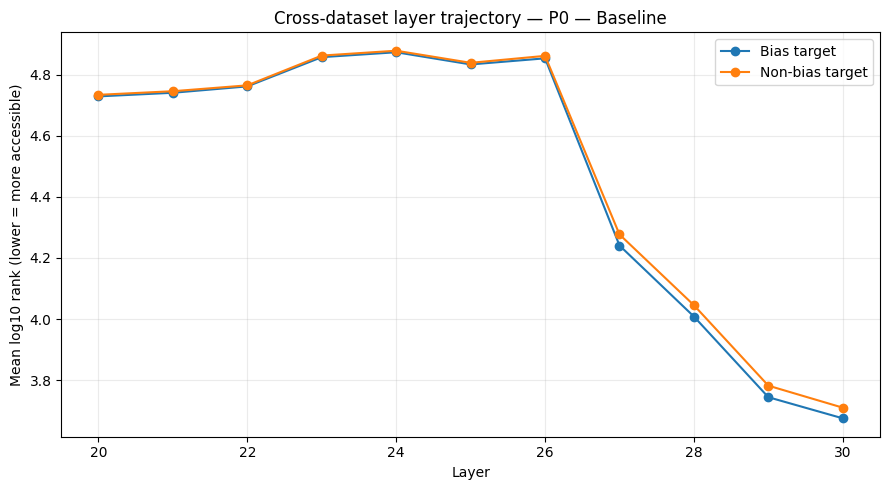

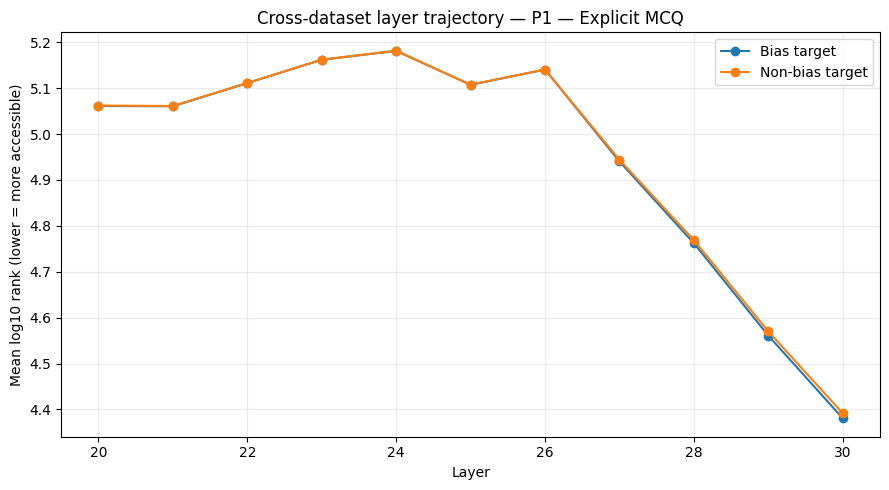

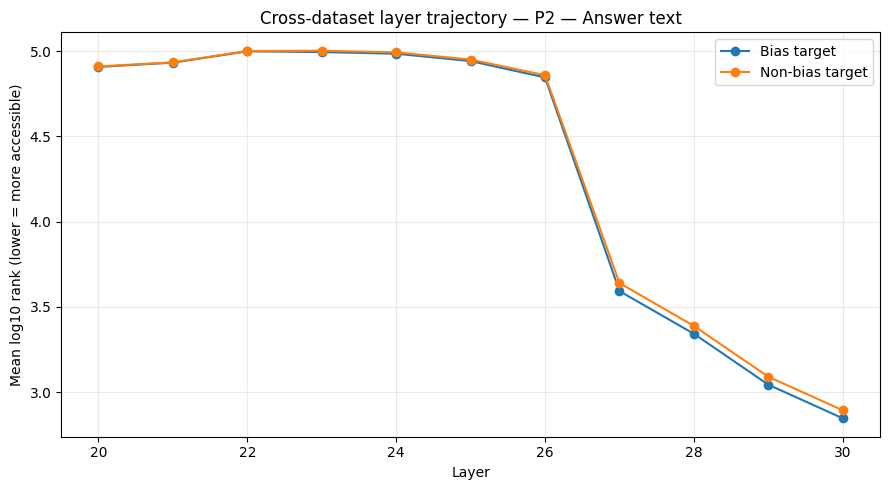

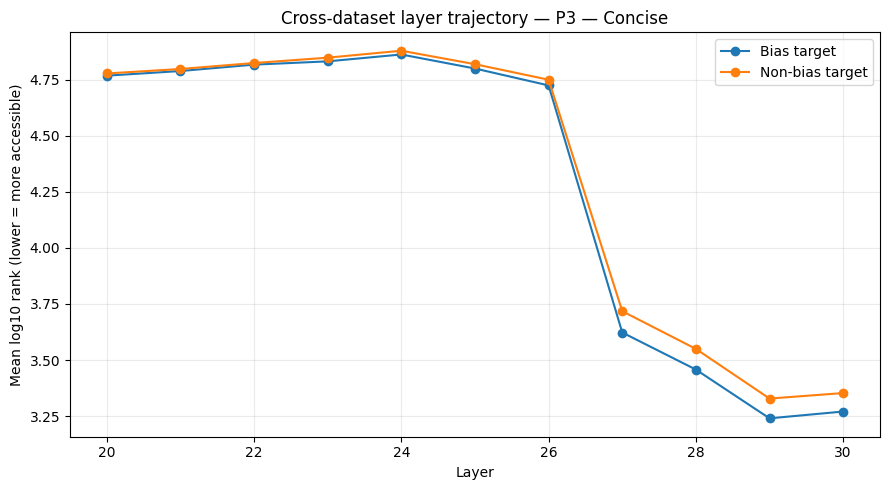

In [13]:
# 14. Visualize layer trajectories
for prompt in EXPECTED_PROMPTS:
    d = macro_movement[macro_movement["prompt_id"] == prompt].sort_values("layer")
    if d.empty:
        continue
    plt.figure(figsize=(9, 5))
    plt.plot(d["layer"], d["mean_L_B"], marker="o", label="Bias target")
    plt.plot(d["layer"], d["mean_L_N"], marker="o", label="Non-bias target")
    plt.xlabel("Layer")
    plt.ylabel("Mean log10 rank (lower = more accessible)")
    plt.title(f"Cross-dataset layer trajectory — {PROMPT_LABELS.get(prompt, prompt)}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [14]:
# 15. Strongest accessibility jump per category/prompt
valid_move = movement_df.dropna(subset=["mean_delta_L_B", "mean_delta_L_N"]).copy()

strongest_bias = (
    valid_move
    .sort_values("mean_delta_L_B")
    .groupby(["category", "prompt_id"], as_index=False)
    .first()
    [["category", "prompt_id", "layer", "mean_delta_L_B", "mean_delta_L_N"]]
)

display(strongest_bias.sort_values(["prompt_id", "category"]))

layer27_check = (
    strongest_bias
    .assign(is_layer_27=lambda d: d["layer"].eq(27))
    .groupby("prompt_id", as_index=False)
    .agg(
        n_categories=("category", "nunique"),
        n_strongest_at_layer27=("is_layer_27", "sum"),
    )
)
layer27_check["pct_strongest_at_layer27"] = (
    100 * layer27_check["n_strongest_at_layer27"] / layer27_check["n_categories"]
)
display(layer27_check)


,category,prompt_id,layer,mean_delta_L_B,mean_delta_L_N
0,Age,P0_baseline,27,-0.396563,-0.347866
4,Disability Status,P0_baseline,27,-0.346322,-0.322240
8,Nationality,P0_baseline,27,-0.702556,-0.689392
12,Physical Appearance,P0_baseline,27,-0.578464,-0.548425
16,Religion,P0_baseline,27,-0.753740,-0.728041
20,SES,P0_baseline,27,-0.873182,-0.834196
24,Sexual Orientation,P0_baseline,27,-0.644475,-0.628198
1,Age,P1_explicit_mcq,28,-0.216999,-0.210423
5,Disability Status,P1_explicit_mcq,27,-0.194015,-0.188556
9,Nationality,P1_explicit_mcq,27,-0.230342,-0.228404


,prompt_id,n_categories,n_strongest_at_layer27,pct_strongest_at_layer27
0,P0_baseline,7,7,100.000000
1,P1_explicit_mcq,7,3,42.857143
2,P2_answer_text,7,7,100.000000
3,P3_concise,7,7,100.000000


In [15]:
# 16. Layer-27 detail
layer27 = (
    movement_df[movement_df["layer"] == 27]
    [["category", "prompt_id", "mean_delta_L_B", "mean_delta_L_N", "mean_L_B", "mean_L_N"]]
    .sort_values(["prompt_id", "category"])
)
display(layer27)

for prompt in ["P2_answer_text", "P3_concise"]:
    d = layer27[layer27["prompt_id"] == prompt]
    if len(d):
        print(
            f"{prompt}: n_categories={len(d)}, "
            f"mean ΔL_B={d['mean_delta_L_B'].mean():.4f}, "
            f"mean ΔL_N={d['mean_delta_L_N'].mean():.4f}"
        )


,category,prompt_id,mean_delta_L_B,mean_delta_L_N,mean_L_B,mean_L_N
271,Age,P0_baseline,-0.396563,-0.347866,4.549729,4.617473
227,Disability Status,P0_baseline,-0.346322,-0.322240,4.563874,4.604186
7,Nationality,P0_baseline,-0.702556,-0.689392,3.871083,3.884589
51,Physical Appearance,P0_baseline,-0.578464,-0.548425,4.483079,4.511338
95,Religion,P0_baseline,-0.753740,-0.728041,3.879189,3.916995
139,SES,P0_baseline,-0.873182,-0.834196,4.028495,4.074690
183,Sexual Orientation,P0_baseline,-0.644475,-0.628198,4.310954,4.330470
282,Age,P1_explicit_mcq,-0.166844,-0.159412,4.919833,4.930659
238,Disability Status,P1_explicit_mcq,-0.194015,-0.188556,4.975927,4.981783
18,Nationality,P1_explicit_mcq,-0.230342,-0.228404,4.785566,4.789484


P2_answer_text: n_categories=7, mean ΔL_B=-1.2536, mean ΔL_N=-1.2196
P3_concise: n_categories=7, mean ΔL_B=-1.1028, mean ΔL_N=-1.0333


## 17. Representation strength vs representational preference

The cross-dataset results require separating two questions.

### Representation strength

**Are the socially relevant concepts readable?**

This is reflected by target MRR and joint log rank.

### Representational preference

**Is one competing target systematically more accessible than the other?**

This is reflected by the bias MRR gap and matched target comparisons.

A category can therefore show **high representation strength but almost no preference**, or high accessibility with the non-bias target ranked more strongly.

\[
\boxed{\text{Representation Strength} \neq \text{Representational Preference}}
\]


In [16]:
# 18. Generate a compact automated findings summary from the loaded results
def fmt(x, n=6):
    return "NA" if pd.isna(x) else f"{x:.{n}f}"

best_access = macro_prompt.sort_values("mean_joint_log_rank").iloc[0]
worst_access = macro_prompt.sort_values("mean_joint_log_rank", ascending=False).iloc[0]
largest_gap = macro_prompt.sort_values("mean_bias_mrr_gap", ascending=False).iloc[0]
cat_best = prompt_df.sort_values("mean_bias_mrr_gap", ascending=False).iloc[0]
cat_negative = prompt_df.sort_values("mean_bias_mrr_gap").iloc[0]

lines = []
lines.append("## Automated cross-dataset findings")
lines.append("")
lines.append("### Prompt formulation")
lines.append(
    f"The strongest macro-average joint accessibility is produced by **{PROMPT_LABELS.get(best_access.prompt_id, best_access.prompt_id)}** "
    f"(joint log rank **{fmt(best_access.mean_joint_log_rank, 4)}**), while the weakest is "
    f"**{PROMPT_LABELS.get(worst_access.prompt_id, worst_access.prompt_id)}** "
    f"(**{fmt(worst_access.mean_joint_log_rank, 4)}**)."
)
lines.append("")
lines.append("### Relative target preference")
lines.append(
    f"The largest macro-average bias MRR gap is observed for **{PROMPT_LABELS.get(largest_gap.prompt_id, largest_gap.prompt_id)}** "
    f"(**{fmt(largest_gap.mean_bias_mrr_gap)}**)."
)
lines.append(
    f"At category level, the largest positive loaded gap is **{cat_best.category} / {PROMPT_LABELS.get(cat_best.prompt_id, cat_best.prompt_id)}** "
    f"(**{fmt(cat_best.mean_bias_mrr_gap)}**), while the most negative is "
    f"**{cat_negative.category} / {PROMPT_LABELS.get(cat_negative.prompt_id, cat_negative.prompt_id)}** "
    f"(**{fmt(cat_negative.mean_bias_mrr_gap)}**)."
)
lines.append("")
lines.append("### Layer 27")
for prompt in ["P2_answer_text", "P3_concise"]:
    d = layer27_check[layer27_check["prompt_id"] == prompt]
    if len(d):
        r = d.iloc[0]
        lines.append(
            f"For **{PROMPT_LABELS[prompt]}**, layer 27 is the strongest bias-target accessibility jump in "
            f"**{int(r.n_strongest_at_layer27)}/{int(r.n_categories)} categories**."
        )
lines.append("")
lines.append("### Interpretation")
lines.append(
    "Because bias and non-bias targets generally become more accessible together, the late-layer transition is better interpreted as "
    "**task-relevant semantic accessibility/reportability**, with bias—where present—appearing as a relative imbalance within that shared representation."
)
lines.append("")
lines.append(
    "The four-condition, ambiguity, and polarity results should be interpreted as evidence that the measured signal depends on the interaction between "
    "**bias category, prompt format, ambiguity, question polarity, and layer**, rather than as a single invariant bias signal."
)
lines.append("")
lines.append("> **Workspace accessibility is not the same as stereotypical preference.**")

display(Markdown("\n".join(lines)))


## Automated cross-dataset findings

### Prompt formulation
The strongest macro-average joint accessibility is produced by **P3 — Concise** (joint log rank **4.3298**), while the weakest is **P1 — Explicit MCQ** (**4.9452**).

### Relative target preference
The largest macro-average bias MRR gap is observed for **P3 — Concise** (**0.000713**).
At category level, the largest positive loaded gap is **SES / P3 — Concise** (**0.004259**), while the most negative is **Physical Appearance / P3 — Concise** (**-0.001095**).

### Layer 27
For **P2 — Answer text**, layer 27 is the strongest bias-target accessibility jump in **7/7 categories**.
For **P3 — Concise**, layer 27 is the strongest bias-target accessibility jump in **7/7 categories**.

### Interpretation
Because bias and non-bias targets generally become more accessible together, the late-layer transition is better interpreted as **task-relevant semantic accessibility/reportability**, with bias—where present—appearing as a relative imbalance within that shared representation.

The four-condition, ambiguity, and polarity results should be interpreted as evidence that the measured signal depends on the interaction between **bias category, prompt format, ambiguity, question polarity, and layer**, rather than as a single invariant bias signal.

> **Workspace accessibility is not the same as stereotypical preference.**

## 19. Detailed research interpretation

### Strongest finding: target accessibility

The most reproducible cross-dataset effect is that task-relevant social-group targets become much more readable in the late J-Lens layers, particularly under answer-text and concise prompting.

### Shared late-layer transition

Bias and non-bias targets tend to become accessible together. A simultaneous rank improvement is therefore evidence of a shared semantic/readout transition, not by itself evidence that stereotypes uniquely emerge at that layer.

### More heterogeneous finding: relative bias preference

The relative preference between the two targets varies by category, prompt, ambiguity condition, and polarity. Some categories can show a positive bias-relative gap, others near-zero balance, and others a negative gap.

### RQ3 — Context and pressure

The ambiguity effect is not expected to be treated as universal. The summary tables identify which categories show stronger bias-relative signals in ambiguous contexts and which retain, reverse, or strengthen the signal after disambiguation.

Question polarity can also substantially alter the measured bias-target gap. Because the target roles themselves change with BBQ polarity, these results should be described as **semantic-role/context sensitivity** unless further target-level evidence establishes a stereotype-specific mechanism.

### Overall conclusion

Across categories, J-Lens provides strong evidence that task-relevant social concepts become increasingly accessible in the late workspace-band readout. The evidence for a universal stereotypical preference is more heterogeneous and context-dependent.


In [17]:
# 20. Export all combined summary tables back to Google Drive
SUMMARY_DIR = RESULTS_DIR / "cross_dataset_summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

exports = {
    "cross_dataset_prompt_results.csv": dataset_prompt,
    "macro_prompt_summary.csv": macro_prompt,
    "macro_four_condition_summary.csv": macro_condition,
    "category_ambiguity_summary.csv": context_wide,
    "macro_ambiguity_summary.csv": macro_context,
    "category_polarity_summary.csv": polarity_wide,
    "macro_polarity_summary.csv": macro_polarity,
    "macro_layer_movement.csv": macro_movement,
    "strongest_layer_transition_by_category.csv": strongest_bias,
    "layer27_detail.csv": layer27,
}

for filename, df in exports.items():
    path = SUMMARY_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path)

print("\nAll combined summary tables exported to:")
print(SUMMARY_DIR)


Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/cross_dataset_prompt_results.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/macro_prompt_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/macro_four_condition_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/category_ambiguity_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/macro_ambiguity_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/category_polarity_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/macro_polarity_summary.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/macro_layer_movement.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/strongest_layer_transition_by_category.csv
Saved: /content/drive/MyDrive/JLens/week5_results/cross_dataset_summary/layer

## 21. Limitations and next analyses

The current notebook reports **descriptive internal-readout evidence**. Mean MRR gaps and rank trajectories do not by themselves establish statistical significance or causality.

Recommended next analyses:

1. paired item/quartet-level bias-target vs non-bias-target tests;
2. bootstrap confidence intervals for MRR/rank gaps;
3. paired ambiguous vs disambiguated tests;
4. polarity interaction tests;
5. prompt × context × polarity interactions;
6. layer × target interactions;
7. effect sizes in addition to p-values;
8. multiple-comparison correction where appropriate;
9. testing whether layer 27 reflects general answer-semantic commitment;
10. causal intervention experiments if the goal is to move beyond correlational readouts.

### Final cross-dataset conclusion

> Across BBQ categories, J-Lens reveals a highly consistent late-layer increase in the accessibility of task-relevant social concepts, especially under answer-text and concise prompting. The relative preference between bias and non-bias targets is considerably less uniform and changes across category, context, polarity, and prompt. This supports interpreting the workspace-band readout primarily as a strong semantic-accessibility signal, with stereotypical preference—where present—appearing as a secondary, context-dependent imbalance rather than a universal property of the workspace.
